# Marginal CARMA calibration outputs

Clean figures and numerical summaries used in Section 3 of the paper. The notebook reads the German price exports from notebooks 02 and 03 and writes harmonised PDF figures to `newpaper/figures/calibration`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.stats import norm, norminvgauss

ROOT = Path.cwd().resolve()
if (ROOT / "newpaper" / "figures").exists():
    REPO = ROOT
else:
    REPO = ROOT.parents[1]

GER = REPO / "germany" / "germany23+24+25"
DATA = GER / "data"
KALMAN = DATA / "kalman"
OUTFIG = REPO / "newpaper" / "figures" / "calibration"
OUTFIG.mkdir(parents=True, exist_ok=True)

BLUE = "#1f4e79"
BLACK = "#111111"
GRAY = "#dddddd"

plt.rcParams.update({
    "font.size": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 130,
})

panel = pd.read_csv(DATA / "seasonality" / "german_panel.csv", index_col=0, parse_dates=True)
y = panel["log_price_resid"].to_numpy(float)
y = y[np.isfinite(y)]
y = y - y.mean()
N = len(y)
v0 = float(y @ y / N)

with open(KALMAN / "price_multiscale_carma_selected.json", "r") as fh:
    multiscale = json.load(fh)
with open(KALMAN / "price_carma54_joint_qmle_result.json", "r") as fh:
    qmle = json.load(fh)
with open(KALMAN / "price_carma54_driver_fits.json", "r") as fh:
    driver = json.load(fh)

print(f"N = {N:,}")
print(f"sample variance = {v0:.6e}")
print(f"CARMA order = {tuple(qmle['carma_order'])}")


N = 26,305
sample variance = 1.256839e-03
CARMA order = (5, 4)


In [2]:
def empirical_acf(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(x @ x / len(x))
    out = np.empty(max_lag + 1)
    out[0] = 1.0
    for k in range(1, max_lag + 1):
        out[k] = float(x[:-k] @ x[k:] / ((len(x) - k) * denom))
    return out


def multiscale_acf(payload, lags):
    lags = np.asarray(lags, dtype=float)
    out = np.zeros_like(lags)
    for comp in payload["components"]:
        hl = float(comp["half_life_h"])
        kap = np.log(2.0) / hl
        share = float(comp["share"])
        if comp["kind"] == "osc":
            omega = 2.0 * np.pi / float(comp["period_h"])
            out += share * np.exp(-kap * lags) * np.cos(omega * lags)
        else:
            out += share * np.exp(-kap * lags)
    return out


def companion_from_ar(ar):
    ar = np.asarray(ar, dtype=float)
    p = len(ar)
    A = np.zeros((p, p))
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -ar[::-1]
    return A


def carma_acf(ar, b, lags):
    ar = np.asarray(ar, dtype=float)
    b = np.asarray(b, dtype=float)
    p = len(ar)
    if len(b) < p:
        b = np.r_[b, np.zeros(p - len(b))]
    A = companion_from_ar(ar)
    ep = np.zeros(p)
    ep[-1] = 1.0
    P = solve_continuous_lyapunov(A, -np.outer(ep, ep))
    Pb = P @ b
    var0 = float(b @ Pb)
    vals = []
    for h in np.asarray(lags, dtype=float):
        vals.append(float((expm(A * h) @ Pb) @ b / var0))
    return np.asarray(vals)

MAX_LAG = 700
lags = np.arange(MAX_LAG + 1)
rho_emp = empirical_acf(y, MAX_LAG)
rho_ms = multiscale_acf(multiscale, lags)
rho_qmle = carma_acf(qmle["ar_coefficients"], qmle["b_coefficients"], lags)

print("multiscale components")
print(pd.DataFrame(multiscale["components"]))
print("\nQMLE AR real half-lives h:", qmle["ar_real_half_lives_h"])
print("QMLE AR complex half-life h:", qmle["ar_complex_half_life_h"])
print("QMLE AR complex period h:", qmle["ar_complex_period_h"])


multiscale components


         kind  half_life_h  half_life_d  period_h     share
0         osc   173.114350     7.213098      24.0  0.054732
1        real     2.630935     0.109622       NaN  0.287530
2        real    28.688739     1.195364       NaN  0.544009
3  real_fixed  2880.000000   120.000000       NaN  0.113728

QMLE AR real half-lives h: [4.5235497726807115, 35.93564854796266, 1976.6669189746556]
QMLE AR complex half-life h: 173.11435003387103
QMLE AR complex period h: 24.0


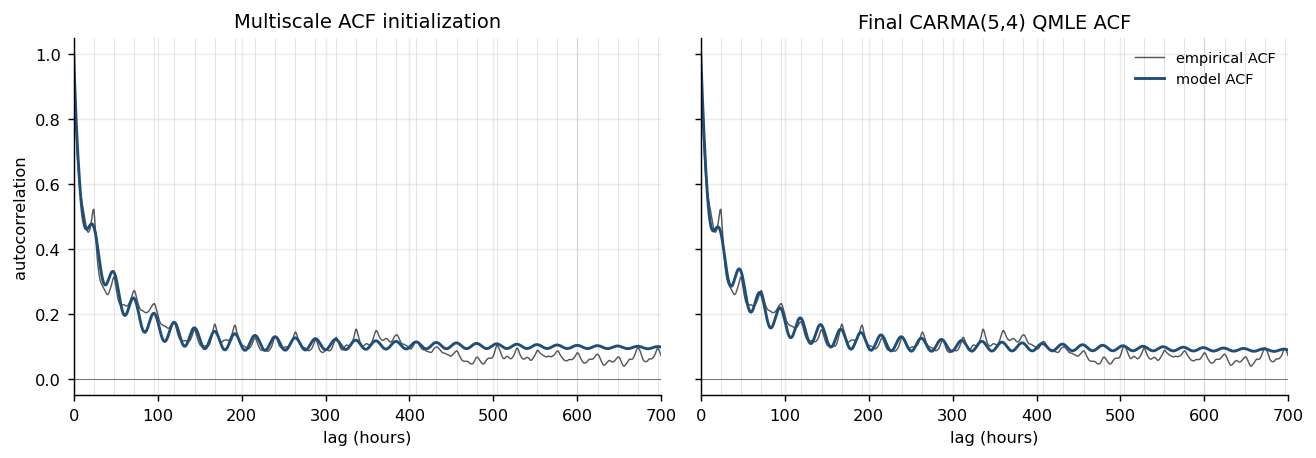

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\price_spot_acf_calibration_700.pdf


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)

for ax, model, title in [
    (axes[0], rho_ms, "Multiscale ACF initialization"),
    (axes[1], rho_qmle, "Final CARMA(5,4) QMLE ACF"),
]:
    ax.plot(lags[1:], rho_emp[1:], color=BLACK, lw=0.8, alpha=0.70, label="empirical ACF")
    ax.plot(lags, model, color=BLUE, lw=1.6, label="model ACF")
    for h in range(24, MAX_LAG + 1, 24):
        ax.axvline(h, color=GRAY, lw=0.45, zorder=0)
    ax.axhline(0.0, color="#777777", lw=0.55)
    ax.set_xlim(0, MAX_LAG)
    ax.set_xlabel("lag (hours)")
    ax.set_title(title)

axes[0].set_ylabel("autocorrelation")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "price_spot_acf_calibration_700.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


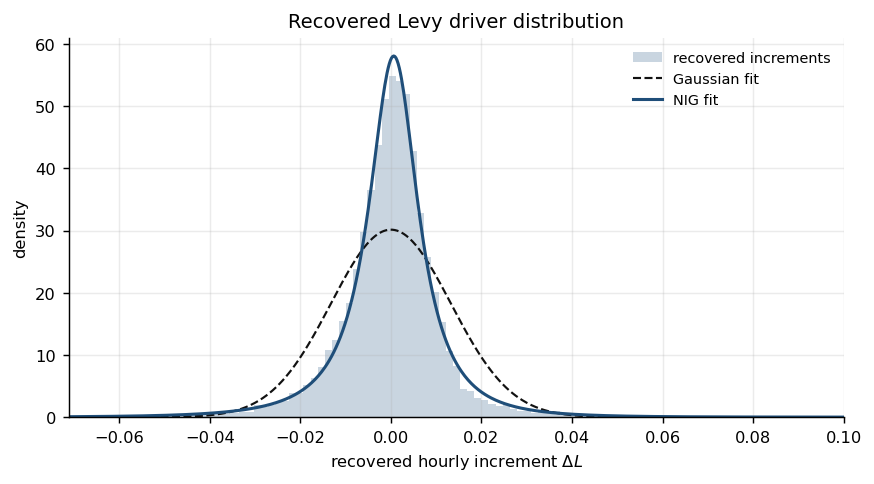

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\price_spot_driver_distribution_fit.pdf
              mean  variance       std    m_rate  nu2_rate        N       mu  \
Gaussian  0.000002  0.000175  0.013236  0.000002  0.000175  26304.0      NaN   
NIG       0.000002  0.000147  0.012135       NaN       NaN    26304  0.00074   

            delta      alpha      beta      gamma   scipy_a   scipy_b  \
Gaussian      NaN        NaN       NaN        NaN       NaN       NaN   
NIG       0.00687  47.467042 -5.073598  47.195113  0.326109 -0.034857   

         scipy_loc scipy_scale        loglik      skew excess_kurtosis  \
Gaussian       NaN         NaN           NaN       NaN             NaN   
NIG        0.00074     0.00687  83441.833483 -0.563133        9.675204   

         success                                            message  
Gaussian     NaN                                                NaN  
NIG         True  CONVERGENCE: RELATIVE REDUCT

In [4]:
dL_npz = np.load(KALMAN / "price_carma54_levy_increments_recovered.npz")
dL = dL_npz["increments"].astype(float)
dL = dL[np.isfinite(dL)]

g = driver["gaussian"]
nig = driver["nig"]
lo, hi = np.quantile(dL, [0.001, 0.999])
x = np.linspace(lo, hi, 700)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bins = np.linspace(lo, hi, 110)
ax.hist(dL, bins=bins, density=True, color="#b8c7d6", edgecolor="none", alpha=0.75, label="recovered increments")
ax.plot(x, norm.pdf(x, loc=g["mean"], scale=g["std"]), color=BLACK, lw=1.2, ls="--", label="Gaussian fit")
ax.plot(x, norminvgauss.pdf(x, nig["scipy_a"], nig["scipy_b"], loc=nig["scipy_loc"], scale=nig["scipy_scale"]), color=BLUE, lw=1.7, label="NIG fit")
ax.set_xlabel(r"recovered hourly increment $\Delta L$")
ax.set_ylabel("density")
ax.set_xlim(lo, hi)
ax.set_title("Recovered Levy driver distribution")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "price_spot_driver_distribution_fit.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print(pd.DataFrame({"Gaussian": g, "NIG": nig}).T)


In [5]:
def psd_sqrt(M, tol=1e-12):
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"matrix is not PSD: min eigenvalue={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def discrete_noise_covariance(A, ep, Delta=1.0):
    p = A.shape[0]
    M = np.zeros((2 * p, 2 * p))
    M[:p, :p] = A
    M[:p, p:] = np.outer(ep, ep)
    M[p:, p:] = -A.T
    E = expm(M * Delta)
    F = E[:p, :p]
    Q = E[:p, p:] @ F.T
    return 0.5 * (Q + Q.T)


def simulate_gaussian_carma(A, b, driver_fit, n_steps, n_paths, seed=20260621):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    ep = np.zeros(p)
    ep[-1] = 1.0
    F = expm(A)
    Pi1 = solve_continuous_lyapunov(A, -np.outer(ep, ep))
    Q = discrete_noise_covariance(A, ep)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q)

    m_rate = float(driver_fit["m_rate"])
    nu2_rate = float(driver_fit["nu2_rate"])
    state_mean = m_rate * np.linalg.solve(-A, ep)
    drift_step = m_rate * np.linalg.solve(A, (F - np.eye(p)) @ ep)

    X = state_mean + np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))
    for t in range(n_steps):
        shock = np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + drift_step + shock
        Y[:, t] = X @ b
    return Y


def simulate_nig_carma_midpoint(A, b, nig_fit, n_steps, n_paths, burnin=5000, seed=20260622):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    ep = np.zeros(p)
    ep[-1] = 1.0
    F = expm(A)
    shock_vec = expm(A * 0.5) @ ep
    mean_dL = float(nig_fit["mean"])
    state_mean = np.linalg.solve(np.eye(p) - F, shock_vec * mean_dL)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))
    dL_all = norminvgauss.rvs(
        nig_fit["scipy_a"],
        nig_fit["scipy_b"],
        loc=nig_fit["scipy_loc"],
        scale=nig_fit["scipy_scale"],
        size=(n_paths, n_steps + burnin),
        random_state=rng,
    )

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL_all[:, t, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b
            out_i += 1
    return Y

panel_fit = panel.dropna(subset=["price_raw", "log_price", "log_price_seasonal", "log_price_resid"]).copy()
price_obs = panel_fit["price_raw"].to_numpy(float)
log_price_obs = panel_fit["log_price"].to_numpy(float)
log_price_seasonal = panel_fit["log_price_seasonal"].to_numpy(float)
y_obs = panel_fit["log_price_resid"].to_numpy(float)
price_shift = float(np.median(np.exp(log_price_obs) - price_obs))

ar = np.asarray(qmle["ar_coefficients"], dtype=float)
b = np.asarray(qmle["b_coefficients"], dtype=float)
A = companion_from_ar(ar)

N_PATHS = 250
gaussian_paths = simulate_gaussian_carma(A, b, driver["gaussian"], len(y_obs), N_PATHS)
nig_paths = simulate_nig_carma_midpoint(A, b, driver["nig"], len(y_obs), N_PATHS)

gaussian_log_price = log_price_seasonal[None, :] + gaussian_paths
nig_log_price = log_price_seasonal[None, :] + nig_paths

gaussian_price = np.exp(gaussian_log_price) - price_shift
nig_price = np.exp(nig_log_price) - price_shift

print(f"Gaussian paths: {gaussian_paths.shape}")
print(f"NIG paths:      {nig_paths.shape}")
print(f"observed residual std = {np.std(y_obs):.6e}")
print(f"Gaussian residual std = {np.std(gaussian_paths):.6e}")
print(f"NIG residual std      = {np.std(nig_paths):.6e}")


Gaussian paths: (250, 26305)
NIG paths:      (250, 26305)
observed residual std = 3.545192e-02
Gaussian residual std = 3.454280e-02
NIG residual std      = 3.179939e-02


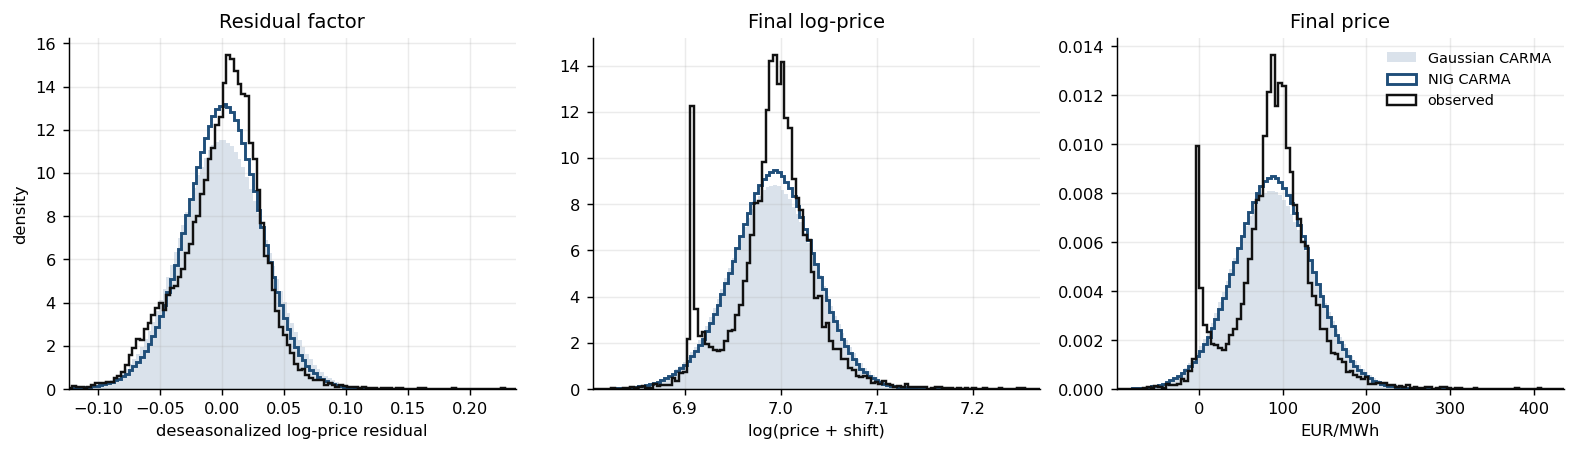

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\price_spot_distribution_checks.pdf


                            mean          std            1%            5%          50%          95%          99%
observed_residual  -4.644104e-07 3.545259e-02 -8.252914e-02 -5.970823e-02 3.420037e-03 4.725925e-02 7.915109e-02
gaussian_residual   6.099367e-04 3.454280e-02 -7.970194e-02 -5.616529e-02 5.895245e-04 5.750243e-02 8.108123e-02
nig_residual        4.154886e-04 3.179939e-02 -7.842860e-02 -5.225524e-02 9.061543e-04 5.146557e-02 7.475651e-02
observed_log_price  6.990761e+00 4.669817e-02  6.892655e+00  6.907745e+00 6.994043e+00 7.056163e+00 7.108452e+00
nig_log_price       6.991177e+00 4.394476e-02  6.881519e+00  6.917434e+00 6.992013e+00 7.061696e+00 7.091655e+00
observed_price      8.773980e+01 5.146908e+01 -1.498640e+01 -1.000000e-02 9.012000e+01 1.599860e+02 2.222540e+02
nig_price           8.804774e+01 4.770063e+01 -2.589495e+01  9.726207e+00 8.790975e+01 1.664222e+02 2.018947e+02


In [6]:
def distribution_panel(ax, observed, gaussian_sim, nig_sim, xlabel, title):
    observed = np.asarray(observed, dtype=float).ravel()
    gaussian_sim = np.asarray(gaussian_sim, dtype=float).ravel()
    nig_sim = np.asarray(nig_sim, dtype=float).ravel()
    lo = min(np.quantile(observed, 0.001), np.quantile(gaussian_sim, 0.001), np.quantile(nig_sim, 0.001))
    hi = max(np.quantile(observed, 0.999), np.quantile(gaussian_sim, 0.999), np.quantile(nig_sim, 0.999))
    bins = np.linspace(lo, hi, 120)

    ax.hist(gaussian_sim, bins=bins, density=True, color="#d8e1ea", edgecolor="none", alpha=0.95, label="Gaussian CARMA")
    ax.hist(nig_sim, bins=bins, density=True, histtype="step", color=BLUE, lw=1.6, label="NIG CARMA")
    ax.hist(observed, bins=bins, density=True, histtype="step", color=BLACK, lw=1.35, label="observed")
    ax.set_xlim(lo, hi)
    ax.set_xlabel(xlabel)
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.55))
distribution_panel(
    axes[0], y_obs, gaussian_paths, nig_paths,
    "deseasonalized log-price residual", "Residual factor"
)
distribution_panel(
    axes[1], log_price_obs, gaussian_log_price, nig_log_price,
    "log(price + shift)", "Final log-price"
)
distribution_panel(
    axes[2], price_obs, gaussian_price, nig_price,
    "EUR/MWh", "Final price"
)
axes[0].set_ylabel("density")
axes[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig_path = OUTFIG / "price_spot_distribution_checks.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

summary_checks = pd.DataFrame({
    "observed_residual": pd.Series(y_obs).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "gaussian_residual": pd.Series(gaussian_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_residual": pd.Series(nig_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "observed_log_price": pd.Series(log_price_obs).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_log_price": pd.Series(nig_log_price.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "observed_price": pd.Series(price_obs).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_price": pd.Series(nig_price.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
}).T
print(summary_checks[["mean", "std", "1%", "5%", "50%", "95%", "99%"]].to_string(float_format=lambda v: f"{v:.6e}"))


## Temperature CARMA(4,3) calibration outputs

Paper figures for the German temperature residual marginal model.

In [7]:

TEMP = REPO / "temperature"
TCARMA = TEMP / "data" / "carma"

temp_panel = pd.read_csv(TCARMA / "temperature_latent_panel.csv", parse_dates=["datetime"])
temp_panel = temp_panel.dropna(subset=["temperature_c", "temperature_seasonality", "temperature_XtQ"]).copy()
temp_y = temp_panel["temperature_XtQ"].to_numpy(float)
temp_y = temp_y - np.mean(temp_y)

with open(TCARMA / "temperature_multiscale_carma43_selected.json", "r", encoding="utf-8") as fh:
    temp_multiscale = json.load(fh)
with open(TCARMA / "temperature_carma43_joint_qmle_result.json", "r", encoding="utf-8") as fh:
    temp_qmle = json.load(fh)
with open(TCARMA / "temperature_carma43_driver_fits.json", "r", encoding="utf-8") as fh:
    temp_driver = json.load(fh)

MAX_LAG_TEMP = 700
temp_lags = np.arange(MAX_LAG_TEMP + 1)
temp_rho_emp = empirical_acf(temp_y, MAX_LAG_TEMP)
temp_rho_ms = multiscale_acf(temp_multiscale, temp_lags)
temp_rho_qmle = carma_acf(temp_qmle["ar_coefficients"], temp_qmle["b_coefficients"], temp_lags)

print(f"N temperature = {len(temp_y):,}")
print(f"CARMA order = {tuple(temp_qmle['carma_order'])}")
print("multiscale components")
print(pd.DataFrame(temp_multiscale["components"]))
print("\nQMLE AR real half-lives h:", temp_qmle["ar_real_half_lives_h"])
print("QMLE AR complex half-life h:", temp_qmle["ar_complex_half_life_h"])
print("QMLE AR complex period h:", temp_qmle["ar_complex_period_h"])


N temperature = 26,304
CARMA order = (4, 3)
multiscale components
   component  kind  half_life_h  half_life_d  period_h     share
0  real_fast  real    25.474135     1.061422       NaN  0.346094
1   real_mid  real    58.166559     2.423607       NaN  0.614622
2  osc_daily   osc    72.721060     3.030044      24.0  0.039283

QMLE AR real half-lives h: [0.5296912688360469, 38.08873372432216]
QMLE AR complex half-life h: 72.72106045326112
QMLE AR complex period h: 24.0


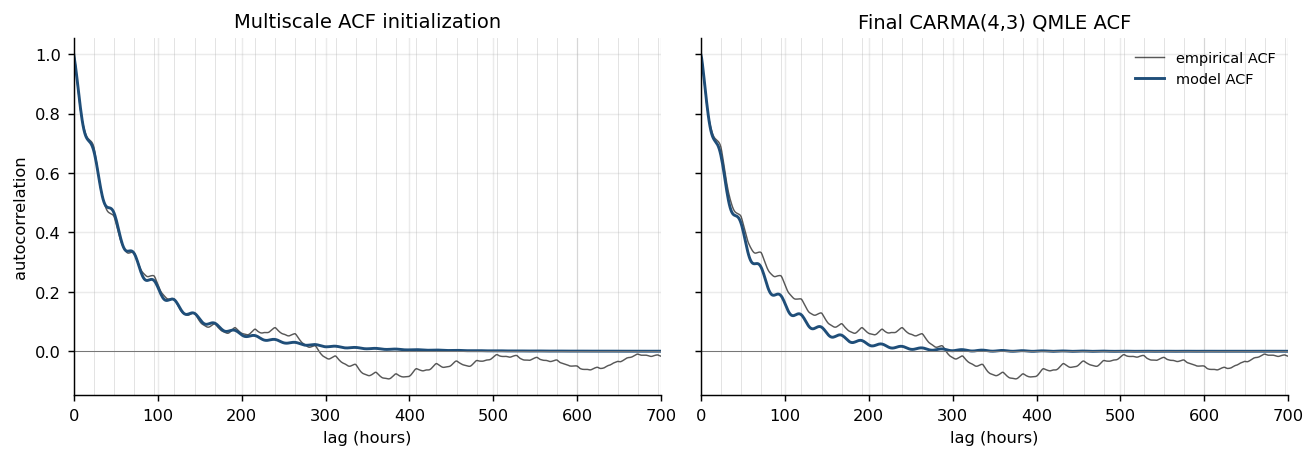

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\temperature_acf_calibration_700.pdf


In [8]:

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)

for ax, model, title in [
    (axes[0], temp_rho_ms, "Multiscale ACF initialization"),
    (axes[1], temp_rho_qmle, "Final CARMA(4,3) QMLE ACF"),
]:
    ax.plot(temp_lags[1:], temp_rho_emp[1:], color=BLACK, lw=0.8, alpha=0.70, label="empirical ACF")
    ax.plot(temp_lags, model, color=BLUE, lw=1.6, label="model ACF")
    for h in range(24, MAX_LAG_TEMP + 1, 24):
        ax.axvline(h, color=GRAY, lw=0.45, zorder=0)
    ax.axhline(0.0, color="#777777", lw=0.55)
    ax.set_xlim(0, MAX_LAG_TEMP)
    ax.set_xlabel("lag (hours)")
    ax.set_title(title)

axes[0].set_ylabel("autocorrelation")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "temperature_acf_calibration_700.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


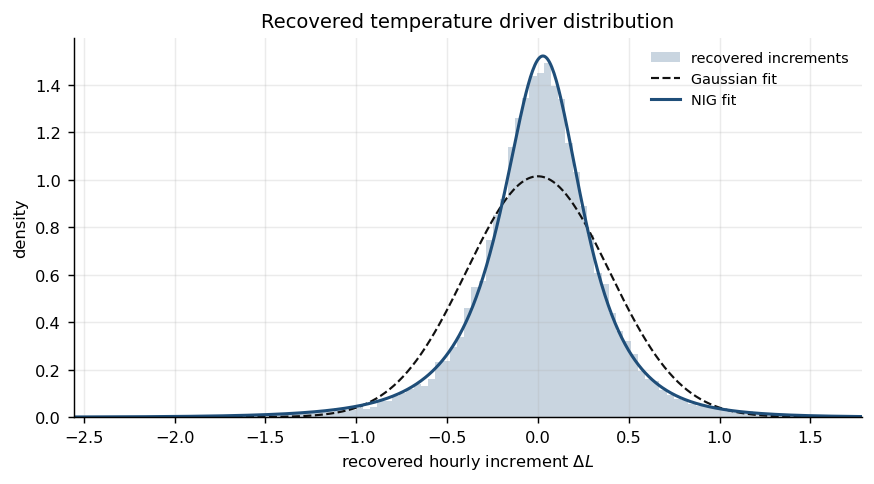

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\temperature_driver_distribution_fit.pdf
              mean  variance       std    m_rate nu2_rate        N        mu  \
Gaussian -0.000258   0.15452  0.393091 -0.000258  0.15452  26303.0       NaN   
NIG      -0.000258  0.148236  0.385014       NaN      NaN    26303  0.037243   

             delta     alpha      beta     gamma   scipy_a   scipy_b  \
Gaussian       NaN       NaN       NaN       NaN       NaN       NaN   
NIG       0.298881  2.064055 -0.256965  2.047997  0.616906 -0.076802   

         scipy_loc scipy_scale       loglik      skew excess_kurtosis success  \
Gaussian       NaN         NaN          NaN       NaN             NaN     NaN   
NIG       0.037243    0.298881 -9716.399487 -0.477376        5.204958    True   

                                                    message  
Gaussian                                                NaN  
NIG       CONVERGENCE: RELATIVE REDUCTION O

In [9]:

temp_dL_npz = np.load(TCARMA / "temperature_carma43_levy_increments_recovered.npz")
temp_dL = temp_dL_npz["increments"].astype(float)
temp_dL = temp_dL[np.isfinite(temp_dL)]

tg = temp_driver["gaussian"]
tnig = temp_driver["nig"]
tlo, thi = np.quantile(temp_dL, [0.001, 0.999])
tx = np.linspace(tlo, thi, 700)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bins = np.linspace(tlo, thi, 110)
ax.hist(temp_dL, bins=bins, density=True, color="#b8c7d6", edgecolor="none", alpha=0.75, label="recovered increments")
ax.plot(tx, norm.pdf(tx, loc=tg["mean"], scale=tg["std"]), color=BLACK, lw=1.2, ls="--", label="Gaussian fit")
ax.plot(
    tx,
    norminvgauss.pdf(tx, tnig["scipy_a"], tnig["scipy_b"], loc=tnig["scipy_loc"], scale=tnig["scipy_scale"]),
    color=BLUE,
    lw=1.7,
    label="NIG fit",
)
ax.set_xlabel(r"recovered hourly increment $\Delta L$")
ax.set_ylabel("density")
ax.set_xlim(tlo, thi)
ax.set_title("Recovered temperature driver distribution")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "temperature_driver_distribution_fit.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print(pd.DataFrame({"Gaussian": tg, "NIG": tnig}).T)


In [10]:

temp_ar = np.asarray(temp_qmle["ar_coefficients"], dtype=float)
temp_b = np.asarray(temp_qmle["b_coefficients"], dtype=float)
temp_A = companion_from_ar(temp_ar)

TEMP_PATHS = 250
temp_gaussian_paths = simulate_gaussian_carma(temp_A, temp_b, temp_driver["gaussian"], len(temp_y), TEMP_PATHS, seed=20260623)
temp_nig_paths = simulate_nig_carma_midpoint(temp_A, temp_b, temp_driver["nig"], len(temp_y), TEMP_PATHS, seed=20260624)

temp_seasonality = temp_panel["temperature_seasonality"].to_numpy(float)
temp_obs = temp_panel["temperature_c"].to_numpy(float)
temp_gaussian_level = temp_seasonality[None, :] + temp_gaussian_paths
temp_nig_level = temp_seasonality[None, :] + temp_nig_paths

temp_obs_delta = np.diff(temp_y)
temp_gaussian_delta = np.diff(temp_gaussian_paths, axis=1)
temp_nig_delta = np.diff(temp_nig_paths, axis=1)

print(f"Gaussian temperature paths: {temp_gaussian_paths.shape}")
print(f"NIG temperature paths:      {temp_nig_paths.shape}")
print(f"observed XtQ std = {np.std(temp_y):.6e}")
print(f"Gaussian XtQ std = {np.std(temp_gaussian_paths):.6e}")
print(f"NIG XtQ std      = {np.std(temp_nig_paths):.6e}")


Gaussian temperature paths: (250, 26304)
NIG temperature paths:      (250, 26304)
observed XtQ std = 3.765669e+00
Gaussian XtQ std = 3.808204e+00
NIG XtQ std      = 3.732985e+00


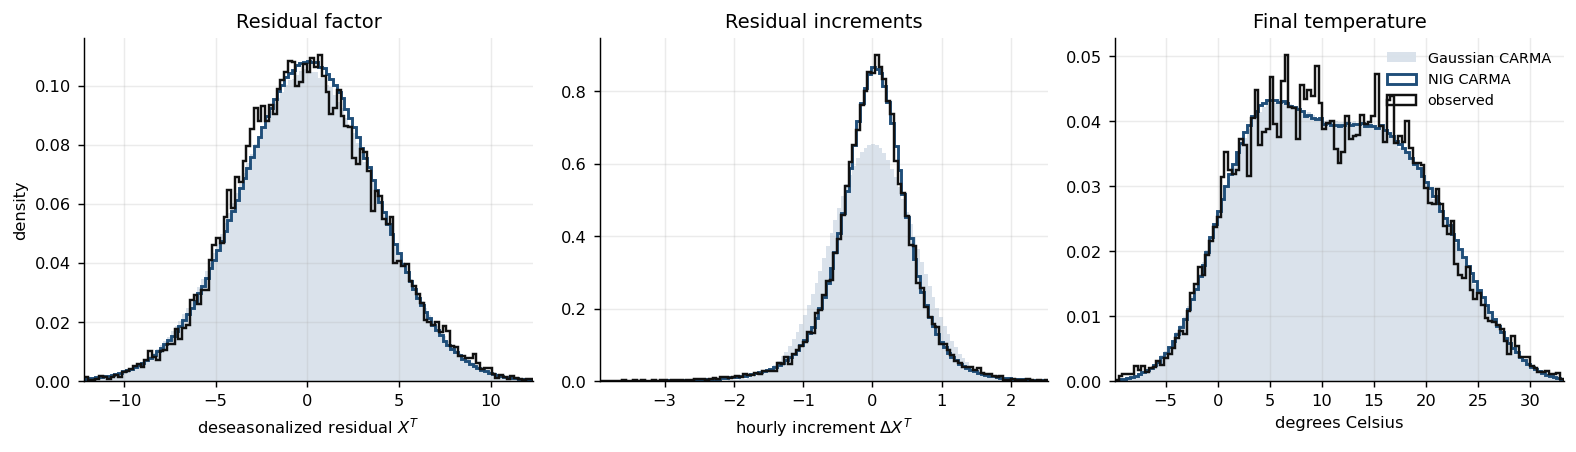

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\temperature_distribution_checks.pdf


                              mean          std            1%            5%           50%          95%          99%
observed_XtQ          8.644072e-18 3.765741e+00 -8.704575e+00 -6.037624e+00 -6.298655e-02 6.283962e+00 8.979315e+00
gaussian_XtQ         -2.704296e-02 3.808205e+00 -8.873994e+00 -6.302470e+00 -2.225573e-02 6.237514e+00 8.838618e+00
nig_XtQ              -9.941220e-03 3.732985e+00 -8.937499e+00 -6.194372e+00  2.009891e-02 6.068930e+00 8.599252e+00
observed_temperature  1.118000e+01 7.995821e+00 -4.800000e+00 -1.092500e+00  1.080000e+01 2.440000e+01 2.880000e+01
nig_temperature       1.117006e+01 7.987096e+00 -4.499317e+00 -1.059842e+00  1.085048e+01 2.447306e+01 2.842195e+01


In [11]:

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.55))
distribution_panel(
    axes[0], temp_y, temp_gaussian_paths, temp_nig_paths,
    r"deseasonalized residual $X^T$", "Residual factor"
)
distribution_panel(
    axes[1], temp_obs_delta, temp_gaussian_delta, temp_nig_delta,
    r"hourly increment $\Delta X^T$", "Residual increments"
)
distribution_panel(
    axes[2], temp_obs, temp_gaussian_level, temp_nig_level,
    "degrees Celsius", "Final temperature"
)
axes[0].set_ylabel("density")
axes[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig_path = OUTFIG / "temperature_distribution_checks.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

temp_summary_checks = pd.DataFrame({
    "observed_XtQ": pd.Series(temp_y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "gaussian_XtQ": pd.Series(temp_gaussian_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_XtQ": pd.Series(temp_nig_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "observed_temperature": pd.Series(temp_obs).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_temperature": pd.Series(temp_nig_level.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
}).T
print(temp_summary_checks[["mean", "std", "1%", "5%", "50%", "95%", "99%"]].to_string(float_format=lambda v: f"{v:.6e}"))


## Solar CARMA(4,3) calibration outputs

Paper figures for the German solar residual marginal model.

In [12]:

from scipy.special import expit

SOLAR = REPO / "solar" / "Intensity_Model_solar"
SCARMA = SOLAR / "data" / "carma"

solar_panel = pd.read_csv(SCARMA / "solar_latent_panel.csv")
solar_time_col = solar_panel.columns[0]
solar_panel[solar_time_col] = pd.to_datetime(solar_panel[solar_time_col])
solar_panel = solar_panel.dropna(
    subset=["solar_cf", "solar_clear_sky", "solar_latent_seasonality", "solar_XtQ"]
).copy()
solar_y = solar_panel["solar_XtQ"].to_numpy(float)
solar_y = solar_y - np.mean(solar_y)

with open(SCARMA / "solar_multiscale_carma43_selected.json", "r", encoding="utf-8") as fh:
    solar_multiscale = json.load(fh)
with open(SCARMA / "solar_carma43_joint_qmle_result.json", "r", encoding="utf-8") as fh:
    solar_qmle = json.load(fh)
with open(SCARMA / "solar_carma43_driver_fits.json", "r", encoding="utf-8") as fh:
    solar_driver = json.load(fh)
with open(SCARMA / "solar_latent_metadata.json", "r", encoding="utf-8") as fh:
    solar_meta = json.load(fh)

MAX_LAG_SOLAR = 700
solar_lags = np.arange(MAX_LAG_SOLAR + 1)
solar_rho_emp = empirical_acf(solar_y, MAX_LAG_SOLAR)
solar_rho_ms = multiscale_acf(solar_multiscale, solar_lags)
solar_rho_qmle = carma_acf(solar_qmle["ar_coefficients"], solar_qmle["b_coefficients"], solar_lags)

print(f"N solar = {len(solar_y):,}")
print(f"CARMA order = {tuple(solar_qmle['carma_order'])}")
print("multiscale components")
print(pd.DataFrame(solar_multiscale["components"]))
print("\nQMLE AR real half-lives h:", solar_qmle["ar_real_half_lives_h"])
print("QMLE AR complex half-life h:", solar_qmle["ar_complex_half_life_h"])
print("QMLE AR complex period h:", solar_qmle["ar_complex_period_h"])


N solar = 40,627


CARMA order = (4, 3)
multiscale components
   component  kind  half_life_h  half_life_d  period_h     share
0  real_fast  real     0.505639     0.021068       NaN  0.459247
1   real_mid  real    41.692992     1.737208       NaN  0.304864
2  osc_daily   osc    70.407265     2.933636      24.0  0.235889

QMLE AR real half-lives h: [0.51195627249817, 37.65150592473537]
QMLE AR complex half-life h: 70.40726491284587
QMLE AR complex period h: 24.0


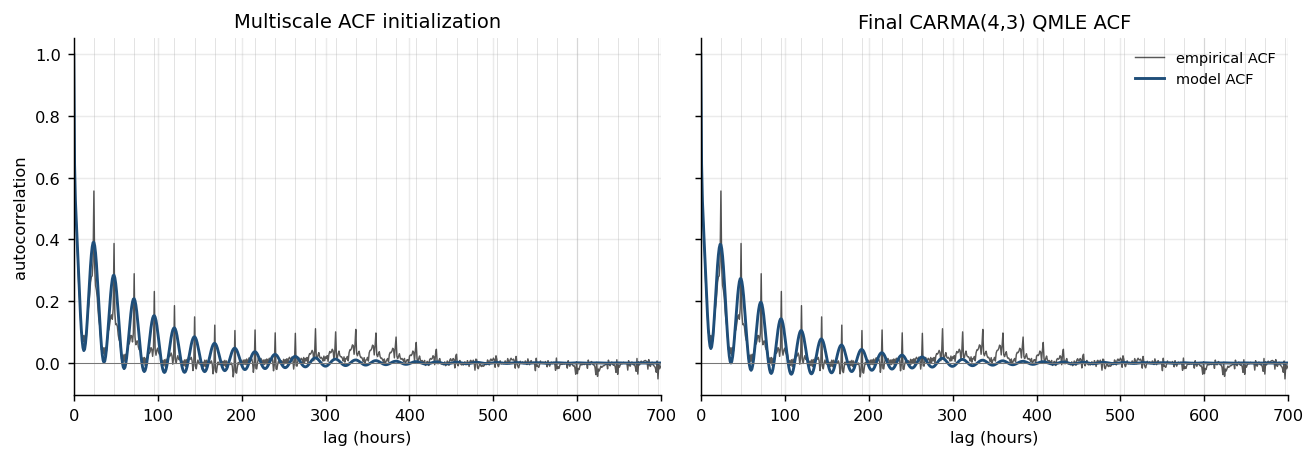

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\solar_acf_calibration_700.pdf


In [13]:

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)

for ax, model, title in [
    (axes[0], solar_rho_ms, "Multiscale ACF initialization"),
    (axes[1], solar_rho_qmle, "Final CARMA(4,3) QMLE ACF"),
]:
    ax.plot(solar_lags[1:], solar_rho_emp[1:], color=BLACK, lw=0.8, alpha=0.70, label="empirical ACF")
    ax.plot(solar_lags, model, color=BLUE, lw=1.6, label="model ACF")
    for h in range(24, MAX_LAG_SOLAR + 1, 24):
        ax.axvline(h, color=GRAY, lw=0.45, zorder=0)
    ax.axhline(0.0, color="#777777", lw=0.55)
    ax.set_xlim(0, MAX_LAG_SOLAR)
    ax.set_xlabel("lag (hours)")
    ax.set_title(title)

axes[0].set_ylabel("autocorrelation")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "solar_acf_calibration_700.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


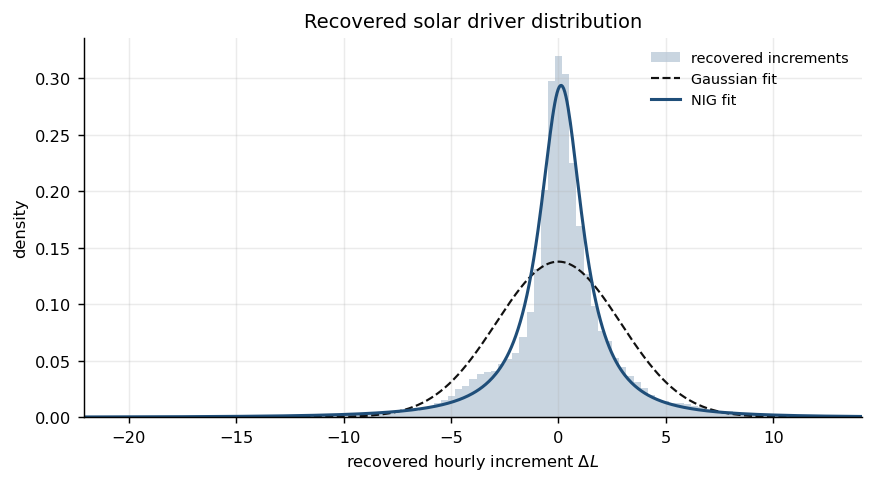

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\solar_driver_distribution_fit.pdf
              mean  variance       std    m_rate nu2_rate        N       mu  \
Gaussian  0.000133   8.38924  2.896419  0.000133  8.38924  40626.0      NaN   
NIG       0.000133  9.253826   3.04201       NaN      NaN    40626  0.13629   

            delta     alpha      beta     gamma   scipy_a   scipy_b scipy_loc  \
Gaussian      NaN       NaN       NaN       NaN       NaN       NaN       NaN   
NIG       1.23683  0.136093 -0.014892  0.135276  0.168324 -0.018419   0.13629   

         scipy_scale        loglik      skew excess_kurtosis success  \
Gaussian         NaN           NaN       NaN             NaN     NaN   
NIG          1.23683 -91909.896748 -0.802549       18.789229    True   

                                                    message  
Gaussian                                                NaN  
NIG       CONVERGENCE: RELATIVE REDUCTION OF F <= FA

In [14]:

solar_dL_npz = np.load(SCARMA / "solar_carma43_levy_increments_recovered.npz")
solar_dL = solar_dL_npz["increments"].astype(float)
solar_dL = solar_dL[np.isfinite(solar_dL)]

sg = solar_driver["gaussian"]
snig = solar_driver["nig"]
slo, shi = np.quantile(solar_dL, [0.001, 0.999])
sx = np.linspace(slo, shi, 700)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bins = np.linspace(slo, shi, 110)
ax.hist(solar_dL, bins=bins, density=True, color="#b8c7d6", edgecolor="none", alpha=0.75, label="recovered increments")
ax.plot(sx, norm.pdf(sx, loc=sg["mean"], scale=sg["std"]), color=BLACK, lw=1.2, ls="--", label="Gaussian fit")
ax.plot(
    sx,
    norminvgauss.pdf(sx, snig["scipy_a"], snig["scipy_b"], loc=snig["scipy_loc"], scale=snig["scipy_scale"]),
    color=BLUE,
    lw=1.7,
    label="NIG fit",
)
ax.set_xlabel(r"recovered hourly increment $\Delta L$")
ax.set_ylabel("density")
ax.set_xlim(slo, shi)
ax.set_title("Recovered solar driver distribution")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "solar_driver_distribution_fit.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print(pd.DataFrame({"Gaussian": sg, "NIG": snig}).T)


In [15]:

solar_ar = np.asarray(solar_qmle["ar_coefficients"], dtype=float)
solar_b = np.asarray(solar_qmle["b_coefficients"], dtype=float)
solar_A = companion_from_ar(solar_ar)

SOLAR_PATHS = 250
solar_gaussian_paths = simulate_gaussian_carma(solar_A, solar_b, solar_driver["gaussian"], len(solar_y), SOLAR_PATHS, seed=20260625)
solar_nig_paths = simulate_nig_carma_midpoint(solar_A, solar_b, solar_driver["nig"], len(solar_y), SOLAR_PATHS, seed=20260626)

solar_seasonality = solar_panel["solar_latent_seasonality"].to_numpy(float)
solar_clear = solar_panel["solar_clear_sky"].to_numpy(float)
solar_obs = solar_panel["solar_cf"].to_numpy(float)
alpha = float(solar_meta["transform"]["alpha"])
beta = float(solar_meta["transform"]["beta"])

def solar_latent_to_cf(latent_paths):
    latent_paths = np.asarray(latent_paths, dtype=float)
    z = solar_seasonality[None, :] + latent_paths
    cf = solar_clear[None, :] * (1.0 - alpha - beta * expit(z))
    return np.clip(cf, 0.0, 1.0)

solar_gaussian_cf = solar_latent_to_cf(solar_gaussian_paths)
solar_nig_cf = solar_latent_to_cf(solar_nig_paths)

solar_obs_delta = np.diff(solar_y)
solar_gaussian_delta = np.diff(solar_gaussian_paths, axis=1)
solar_nig_delta = np.diff(solar_nig_paths, axis=1)

print(f"Gaussian solar paths: {solar_gaussian_paths.shape}")
print(f"NIG solar paths:      {solar_nig_paths.shape}")
print(f"observed XtQ std = {np.std(solar_y):.6e}")
print(f"Gaussian XtQ std = {np.std(solar_gaussian_paths):.6e}")
print(f"NIG XtQ std      = {np.std(solar_nig_paths):.6e}")


Gaussian solar paths: (250, 40627)
NIG solar paths:      (250, 40627)
observed XtQ std = 2.651094e+00
Gaussian XtQ std = 2.583612e+00
NIG XtQ std      = 2.571795e+00


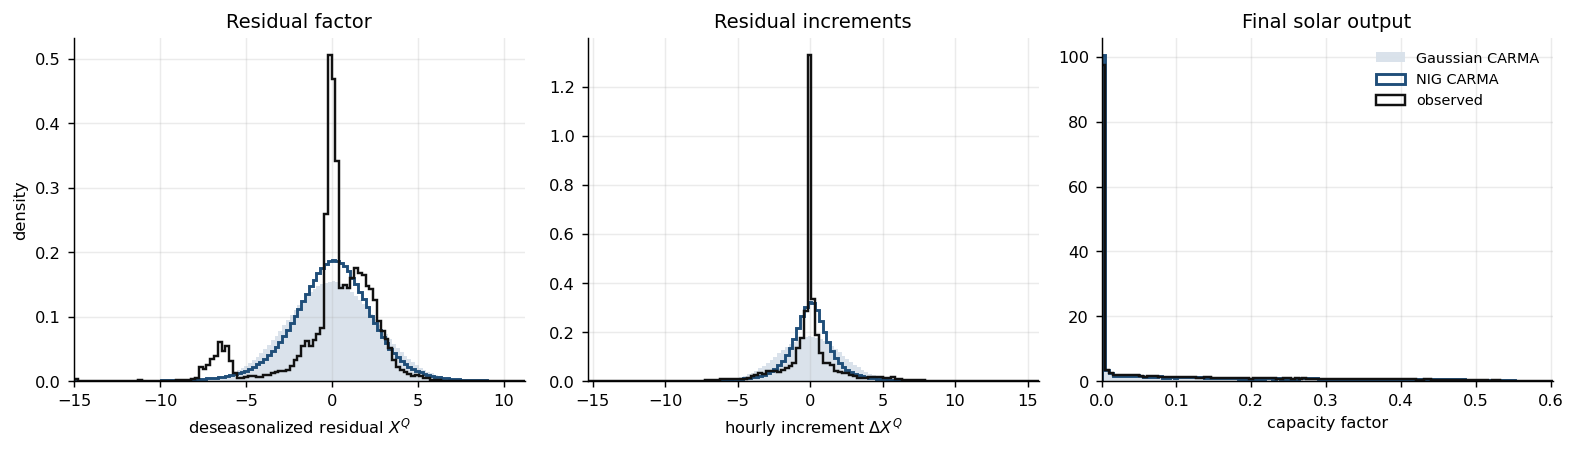

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\solar_distribution_checks.pdf


                          mean          std            1%            5%           50%          95%          99%
observed_XtQ      2.238646e-17 2.651127e+00 -7.583360e+00 -6.443326e+00  2.155766e-01 3.175744e+00 4.629710e+00
gaussian_XtQ      1.930483e-04 2.583612e+00 -6.007873e+00 -4.247886e+00 -1.191980e-03 4.250722e+00 6.013998e+00
nig_XtQ           4.999712e-03 2.571795e+00 -7.003312e+00 -4.061213e+00  6.475323e-02 3.880941e+00 6.334603e+00
observed_solar_cf 1.021566e-01 1.474934e-01  0.000000e+00  0.000000e+00  6.700000e-03 4.286000e-01 5.302220e-01
nig_solar_cf      1.052359e-01 1.540536e-01  0.000000e+00  0.000000e+00  3.377132e-03 4.547126e-01 5.329622e-01


In [16]:

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.55))
distribution_panel(
    axes[0], solar_y, solar_gaussian_paths, solar_nig_paths,
    r"deseasonalized residual $X^Q$", "Residual factor"
)
distribution_panel(
    axes[1], solar_obs_delta, solar_gaussian_delta, solar_nig_delta,
    r"hourly increment $\Delta X^Q$", "Residual increments"
)
distribution_panel(
    axes[2], solar_obs, solar_gaussian_cf, solar_nig_cf,
    "capacity factor", "Final solar output"
)
axes[0].set_ylabel("density")
axes[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig_path = OUTFIG / "solar_distribution_checks.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

solar_summary_checks = pd.DataFrame({
    "observed_XtQ": pd.Series(solar_y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "gaussian_XtQ": pd.Series(solar_gaussian_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_XtQ": pd.Series(solar_nig_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "observed_solar_cf": pd.Series(solar_obs).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_solar_cf": pd.Series(solar_nig_cf.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
}).T
print(solar_summary_checks[["mean", "std", "1%", "5%", "50%", "95%", "99%"]].to_string(float_format=lambda v: f"{v:.6e}"))


## Wind CARMA(4,3) calibration outputs

Paper figures for the German wind residual marginal model.

In [17]:

from scipy.special import expit

WIND = REPO / "wind" / "carma_coupling"
WCARMA = WIND / "data" / "carma"

wind_panel = pd.read_csv(WCARMA / "wind_latent_panel.csv", parse_dates=["datetime"])
wind_panel = wind_panel.dropna(subset=["wind_cf", "wind_logit", "wind_logit_seasonality", "wind_XtQ"]).copy()
wind_y = wind_panel["wind_XtQ"].to_numpy(float)
wind_y = wind_y - np.mean(wind_y)

with open(WCARMA / "wind_multiscale_carma43_selected.json", "r", encoding="utf-8") as fh:
    wind_multiscale = json.load(fh)
with open(WCARMA / "wind_carma43_joint_qmle_result.json", "r", encoding="utf-8") as fh:
    wind_qmle = json.load(fh)
with open(WCARMA / "wind_carma43_driver_fits.json", "r", encoding="utf-8") as fh:
    wind_driver = json.load(fh)

MAX_LAG_WIND = 700
wind_lags = np.arange(MAX_LAG_WIND + 1)
wind_rho_emp = empirical_acf(wind_y, MAX_LAG_WIND)
wind_rho_ms = multiscale_acf(wind_multiscale, wind_lags)
wind_rho_qmle = carma_acf(wind_qmle["ar_coefficients"], wind_qmle["b_coefficients"], wind_lags)

print(f"N wind = {len(wind_y):,}")
print(f"CARMA order = {tuple(wind_qmle['carma_order'])}")
print("multiscale components")
print(pd.DataFrame(wind_multiscale["components"]))
print("\nQMLE AR real half-lives h:", wind_qmle["ar_real_half_lives_h"])
print("QMLE AR complex half-life h:", wind_qmle["ar_complex_half_life_h"])
print("QMLE AR complex period h:", wind_qmle["ar_complex_period_h"])


N wind = 26,305
CARMA order = (4, 3)
multiscale components
   component  kind  half_life_h  half_life_d  period_h     share
0  real_fast  real    16.072654     0.669694       NaN  0.836280
1   real_mid  real   178.507526     7.437814       NaN  0.122855
2  osc_daily   osc    78.795874     3.283161      24.0  0.040866

QMLE AR real half-lives h: [20.91843784674792, 902.4351401380806]
QMLE AR complex half-life h: 78.795874257175
QMLE AR complex period h: 24.0


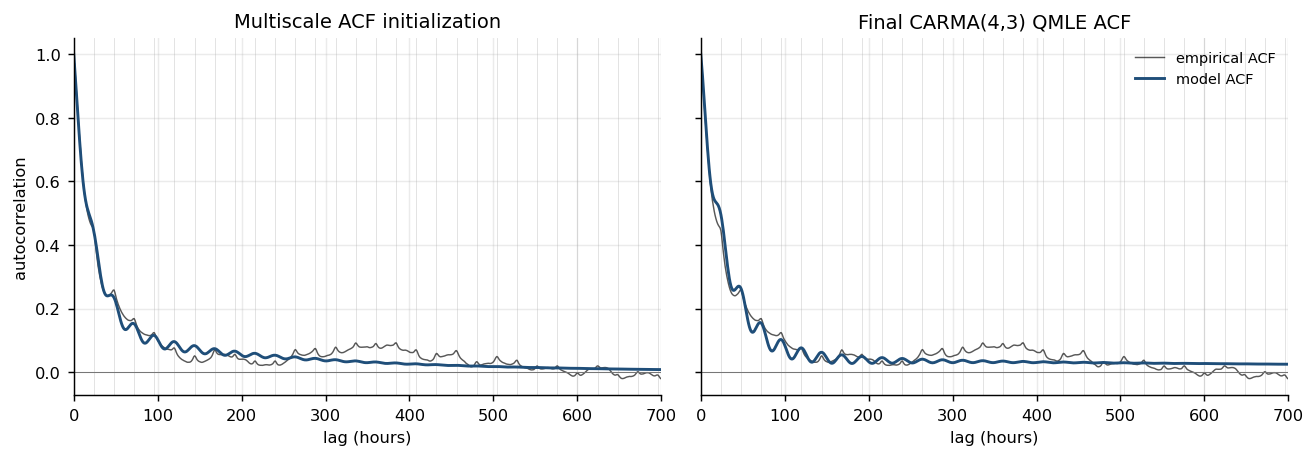

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\wind_acf_calibration_700.pdf


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6), sharey=True)

for ax, model, title in [
    (axes[0], wind_rho_ms, "Multiscale ACF initialization"),
    (axes[1], wind_rho_qmle, "Final CARMA(4,3) QMLE ACF"),
]:
    ax.plot(wind_lags[1:], wind_rho_emp[1:], color=BLACK, lw=0.8, alpha=0.70, label="empirical ACF")
    ax.plot(wind_lags, model, color=BLUE, lw=1.6, label="model ACF")
    for h in range(24, MAX_LAG_WIND + 1, 24):
        ax.axvline(h, color=GRAY, lw=0.45, zorder=0)
    ax.axhline(0.0, color="#777777", lw=0.55)
    ax.set_xlim(0, MAX_LAG_WIND)
    ax.set_xlabel("lag (hours)")
    ax.set_title(title)

axes[0].set_ylabel("autocorrelation")
axes[1].legend(frameon=False, loc="upper right", fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "wind_acf_calibration_700.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


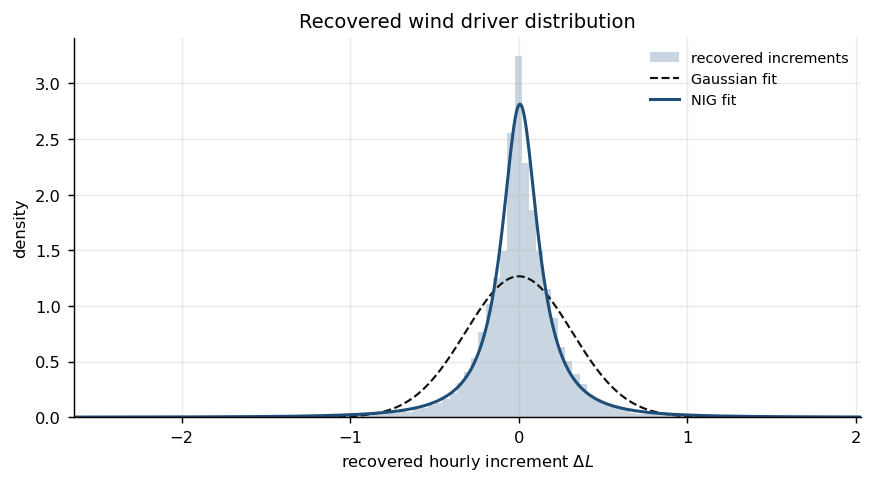

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\wind_driver_distribution_fit.pdf
              mean  variance       std    m_rate  nu2_rate        N        mu  \
Gaussian -0.000278  0.099332  0.315169 -0.000278  0.099332  26304.0       NaN   
NIG      -0.000278   0.08657  0.294229       NaN       NaN    26304  0.007068   

             delta    alpha      beta     gamma  scipy_a   scipy_b scipy_loc  \
Gaussian       NaN      NaN       NaN       NaN      NaN       NaN       NaN   
NIG       0.132178  1.53391 -0.085117  1.531546  0.20275 -0.011251  0.007068   

         scipy_scale       loglik      skew excess_kurtosis success  \
Gaussian         NaN          NaN       NaN             NaN     NaN   
NIG         0.132178  1624.957019 -0.369993       15.001932    True   

                                                    message  
Gaussian                                                NaN  
NIG       CONVERGENCE: RELATIVE REDUCTION OF F <= FAC

In [19]:

wind_dL_npz = np.load(WCARMA / "wind_carma43_levy_increments_recovered.npz")
wind_dL = wind_dL_npz["increments"].astype(float)
wind_dL = wind_dL[np.isfinite(wind_dL)]

wg = wind_driver["gaussian"]
wnig = wind_driver["nig"]
wlo, whi = np.quantile(wind_dL, [0.001, 0.999])
wx = np.linspace(wlo, whi, 700)

fig, ax = plt.subplots(figsize=(6.8, 3.8))
bins = np.linspace(wlo, whi, 110)
ax.hist(wind_dL, bins=bins, density=True, color="#b8c7d6", edgecolor="none", alpha=0.75, label="recovered increments")
ax.plot(wx, norm.pdf(wx, loc=wg["mean"], scale=wg["std"]), color=BLACK, lw=1.2, ls="--", label="Gaussian fit")
ax.plot(
    wx,
    norminvgauss.pdf(wx, wnig["scipy_a"], wnig["scipy_b"], loc=wnig["scipy_loc"], scale=wnig["scipy_scale"]),
    color=BLUE,
    lw=1.7,
    label="NIG fit",
)
ax.set_xlabel(r"recovered hourly increment $\Delta L$")
ax.set_ylabel("density")
ax.set_xlim(wlo, whi)
ax.set_title("Recovered wind driver distribution")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig_path = OUTFIG / "wind_driver_distribution_fit.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")
print(pd.DataFrame({"Gaussian": wg, "NIG": wnig}).T)


In [20]:

wind_ar = np.asarray(wind_qmle["ar_coefficients"], dtype=float)
wind_b = np.asarray(wind_qmle["b_coefficients"], dtype=float)
wind_A = companion_from_ar(wind_ar)

WIND_PATHS = 250
wind_gaussian_paths = simulate_gaussian_carma(wind_A, wind_b, wind_driver["gaussian"], len(wind_y), WIND_PATHS, seed=20260627)
wind_nig_paths = simulate_nig_carma_midpoint(wind_A, wind_b, wind_driver["nig"], len(wind_y), WIND_PATHS, seed=20260628)

wind_seasonality = wind_panel["wind_logit_seasonality"].to_numpy(float)
wind_obs_logit = wind_panel["wind_logit"].to_numpy(float)
wind_obs_cf = wind_panel["wind_cf"].to_numpy(float)

wind_gaussian_logit = wind_seasonality[None, :] + wind_gaussian_paths
wind_nig_logit = wind_seasonality[None, :] + wind_nig_paths
wind_gaussian_cf = expit(np.clip(wind_gaussian_logit, -40.0, 40.0))
wind_nig_cf = expit(np.clip(wind_nig_logit, -40.0, 40.0))

wind_obs_delta = np.diff(wind_y)
wind_gaussian_delta = np.diff(wind_gaussian_paths, axis=1)
wind_nig_delta = np.diff(wind_nig_paths, axis=1)

print(f"Gaussian wind paths: {wind_gaussian_paths.shape}")
print(f"NIG wind paths:      {wind_nig_paths.shape}")
print(f"observed XtQ std = {np.std(wind_y):.6e}")
print(f"Gaussian XtQ std = {np.std(wind_gaussian_paths):.6e}")
print(f"NIG XtQ std      = {np.std(wind_nig_paths):.6e}")


Gaussian wind paths: (250, 26305)
NIG wind paths:      (250, 26305)
observed XtQ std = 1.299078e+00
Gaussian XtQ std = 1.295130e+00
NIG XtQ std      = 1.204881e+00


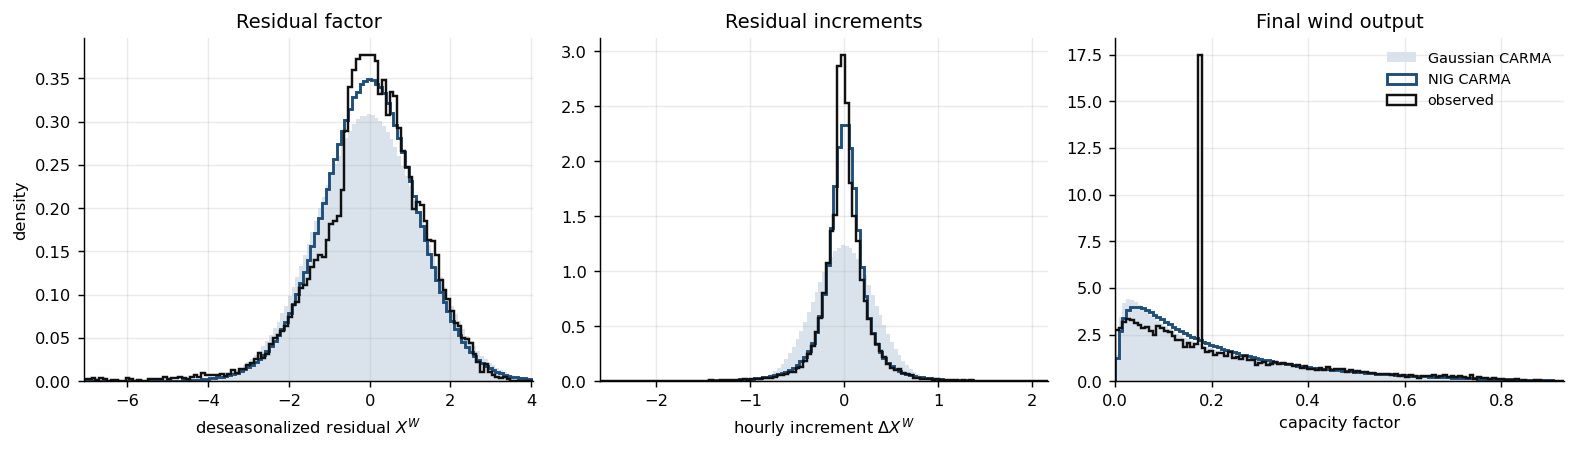

saved C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\newpaper\figures\calibration\wind_distribution_checks.pdf


                          mean          std            1%            5%           50%          95%          99%
observed_XtQ      0.000000e+00 1.299103e+00 -4.012610e+00 -2.168519e+00  6.449153e-02 1.933454e+00 2.581593e+00
gaussian_XtQ     -1.910891e-02 1.295130e+00 -3.028627e+00 -2.149371e+00 -2.033969e-02 2.113245e+00 2.997413e+00
nig_XtQ          -1.211002e-02 1.204881e+00 -2.972691e+00 -1.995353e+00 -3.089681e-03 1.937312e+00 2.853090e+00
observed_wind_cf  2.167105e-01 1.800076e-01  3.004000e-03  1.800000e-02  1.756000e-01 6.105000e-01 7.677960e-01
nig_wind_cf       2.117093e-01 1.829270e-01  8.005032e-03  2.148500e-02  1.550913e-01 5.991710e-01 7.955214e-01


In [21]:

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.55))
distribution_panel(
    axes[0], wind_y, wind_gaussian_paths, wind_nig_paths,
    r"deseasonalized residual $X^W$", "Residual factor"
)
distribution_panel(
    axes[1], wind_obs_delta, wind_gaussian_delta, wind_nig_delta,
    r"hourly increment $\Delta X^W$", "Residual increments"
)
distribution_panel(
    axes[2], wind_obs_cf, wind_gaussian_cf, wind_nig_cf,
    "capacity factor", "Final wind output"
)
axes[0].set_ylabel("density")
axes[2].legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
fig_path = OUTFIG / "wind_distribution_checks.pdf"
fig.savefig(fig_path, bbox_inches="tight")
fig.savefig(fig_path.with_suffix(".png"), dpi=180, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")

wind_summary_checks = pd.DataFrame({
    "observed_XtQ": pd.Series(wind_y).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "gaussian_XtQ": pd.Series(wind_gaussian_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_XtQ": pd.Series(wind_nig_paths.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "observed_wind_cf": pd.Series(wind_obs_cf).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "nig_wind_cf": pd.Series(wind_nig_cf.ravel()).describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
}).T
print(wind_summary_checks[["mean", "std", "1%", "5%", "50%", "95%", "99%"]].to_string(float_format=lambda v: f"{v:.6e}"))
